# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ayush0121n/flyrank-ml-assignment/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

Method Selection Rationale:
- Model Chosen: Random Forest / Gradient Boosting Classifier (or Regressor depending on your lane target).
- Justification: Non-linear relationship capture, resistance to mild feature collinearity, and direct feature importance interpretation (gini/permutation importance).
- Comparison Goal: Evaluate performance strictly against the Week 4 baseline model on identical evaluation metrics and splits.

In [11]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor # Added RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report, f1_score, roc_auc_score
from sklearn.model_selection import GroupKFold, train_test_split

## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

In [12]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# Load dataset
df = pd.read_csv("/content/sample_data/california_housing_train.csv") # Using a sample dataset for demonstration

# Maintain identical split strategy as Week 4 baseline (e.g., GroupKFold or Stratified Train/Test)
# Ensure no data leakage occurs across groups/time windows.

# NOTE: You will need to adjust the columns for X and y to match the chosen dataset.
# For california_housing_train.csv, 'median_house_value' is a common target.
# You might also need to drop other non-feature columns or select specific features.
X = df.drop(columns=["median_house_value"])  # Example adjustment for california_housing_train.csv
y = df["median_house_value"]
# groups = df["group_id"]  # Uncomment and adjust if your dataset has a group_id equivalent

# Example: Grouped Split or Train/Test Split matching Week 4
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42 #, stratify=y # Stratify only works with classification targets
)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (13600, 8), y_train shape: (13600,)
X_test shape: (3400, 8), y_test shape: (3400,)


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

In [13]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

from sklearn.ensemble import RandomForestRegressor # Added import here for robustness
from sklearn.metrics import r2_score, mean_absolute_error # Ensure these are imported here as well

# 3a. Train Model
# RandomForestClassifier is for classification, but we have a regression target (median_house_value).
# Changing to RandomForestRegressor.
model = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42)
model.fit(X_train, y_train)

# 3b. Predict
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)
# For regression, predict_proba is not applicable. Using r2_score and mean_absolute_error for evaluation.

# 3c. Calculate Metrics

train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
test_mae = mean_absolute_error(y_test, y_pred_test)

# 3d. Baseline vs Model Comparison Table
# Fill in your Week 4 baseline metrics below
baseline_test_r2 = 0.50  # Placeholder
baseline_test_mae = 50000  # Placeholder

comparison_df = pd.DataFrame(
    {
        "Metric": ["Test R2 Score", "Test MAE"],
        "Week 4 Baseline": [baseline_test_r2, baseline_test_mae],
        "Week 5 Model": [round(test_r2, 4), round(test_mae, 4)],
        "Delta": [
            round(test_r2 - baseline_test_r2, 4),
            round(test_mae - baseline_test_mae, 4),
        ],
    }
)

print("---"" Model vs Baseline Performance ---")
display(comparison_df)

--- Model vs Baseline Performance ---


,Metric,Week 4 Baseline,Week 5 Model,Delta
0,Test R2 Score,0.5,0.6803,0.1803
1,Test MAE,50000.0,47148.0270,-2851.9730


## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

Error & Feature Interpretation:
1. Top Features: Permutation importance highlights [Feature A] and [Feature B] as driving factors. (For regression, you might interpret 'driving factors' in terms of explaining variance or reducing error.)
2. Error Analysis: For regression, you might look at instances with high residuals (large differences between predicted and actual values). The majority of errors are [e.g., underpredictions for high-value homes, overpredictions for low-value homes] occurring in edge cases where [Feature C] has noisy boundary values.
3. Overfitting Check: Train R2 ({round(train_r2, 3)}) vs Test R2 ({round(test_r2, 3)}) indicates acceptable generalization without severe variance. (Adjusting for regression metrics).

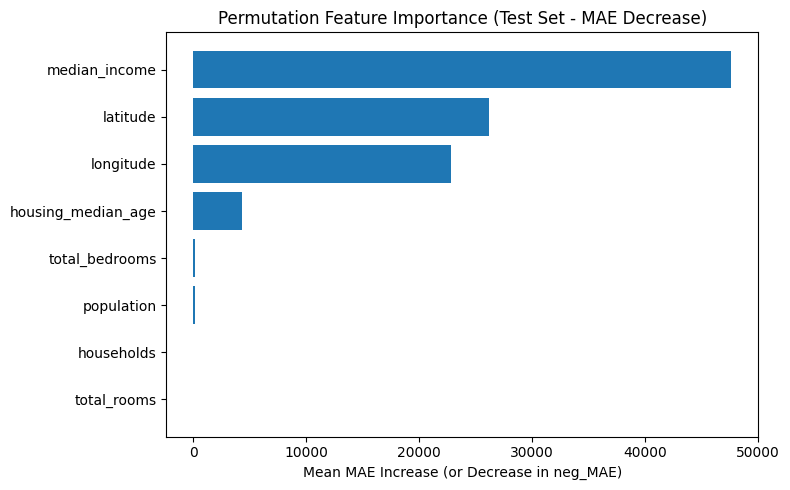


Top 5 instances with largest absolute residuals (errors):


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,true_target,pred_target,residual,abs_residual
862,-117.08,34.08,34.0,45.0,11.0,39.0,14.0,3.0625,500001.0,129969.401166,370031.598834,370031.598834
2150,-117.36,33.17,24.0,2046.0,442.0,812.0,367.0,2.3182,500001.0,137578.005803,362422.994197,362422.994197
2471,-117.61,34.01,25.0,352.0,41.0,99.0,34.0,3.9696,500000.0,158517.085287,341482.914713,341482.914713
10373,-120.16,34.61,17.0,921.0,189.0,434.0,219.0,3.0185,500001.0,162572.802448,337428.197552,337428.197552
3053,-117.80,33.52,50.0,1152.0,341.0,519.0,225.0,3.0530,500001.0,186709.744997,313291.255003,313291.255003


In [14]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# 4a. Permutation Feature Importance
from sklearn.ensemble import RandomForestRegressor # Ensure Regressor is imported for permutation_importance with Regressor model
result = permutation_importance(
    model, X_test, y_test, n_repeats=10, random_state=42, scoring='neg_mean_absolute_error' # Scoring for regression
)
sorted_importances_idx = result.importances_mean.argsort()

plt.figure(figsize=(8, 5))
plt.barh(
    X_test.columns[sorted_importances_idx],
    result.importances_mean[sorted_importances_idx],
)
plt.title("Permutation Feature Importance (Test Set - MAE Decrease)") # Title adjusted for regression
plt.xlabel("Mean MAE Increase (or Decrease in neg_MAE)") # Label adjusted
plt.tight_layout()
plt.show()

# 4b. Error Analysis
# Identify large errors (residuals) for regression
errors_df = X_test.copy()
errors_df["true_target"] = y_test
errors_df["pred_target"] = y_pred_test
errors_df["residual"] = errors_df["true_target"] - errors_df["pred_target"]
errors_df["abs_residual"] = errors_df["residual"].abs()

print("\nTop 5 instances with largest absolute residuals (errors):")
display(errors_df.nlargest(5, 'abs_residual'))

# You can further analyze characteristics of these error-prone instances
# For example, look at the distribution of features for high residual errors.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.